shape: (15460, 25)
Training until validation scores don't improve for 50 rounds


C:\Users\Admin\AppData\Local\Temp\ipykernel_16972\2360690438.py:38: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X.select_dtypes(include=["object"]).columns.tolist()
C:\Users\Admin\AppData\Local\Temp\ipykernel_16972\2360690438.py:49: UserWarning: you are shuffling a 'StringArray' object which is not a subclass of 'Sequence'; `shuffle` is not guaranteed to behave correctly. E.g., non-numpy array/tensor objects with view semantics may contain duplicates after shuffling.
  np.random.shuffle(unique_groups)


[50]	valid's ndcg@1: 0.805017	valid's ndcg@2: 0.862064	valid's ndcg@3: 0.88773	valid's ndcg@4: 0.903926	valid's ndcg@5: 0.914351
Did not meet early stopping. Best iteration is:
[43]	valid's ndcg@1: 0.810309	valid's ndcg@2: 0.863572	valid's ndcg@3: 0.887613	valid's ndcg@4: 0.903275	valid's ndcg@5: 0.915286

===== VALID METRICS =====
{'Top1 Accuracy': 0.7264, 'NDCG@3': np.float64(0.9433279525481539)}

===== TOP 20 FEATURES =====
     feature  importance
23     평균_시속         692
10      경주번호         277
12      마필등급         198
3       기수번호         185
2         마번         184
7       경주일자         180
16       마체중         175
6       출전번호         126
4      조교사번호         110
17       출생일         102
19      소유자명          98
13      출주두수          71
21       부마명          63
24  group_id          53
1         마명          49
18        성별          41
5       부담구분          30
8       경주등급          13
0     분할경주여부          13
11    야간경마여부           4
TRAIN NDCG@3: 0.544290608717737
VALID NDCG@3

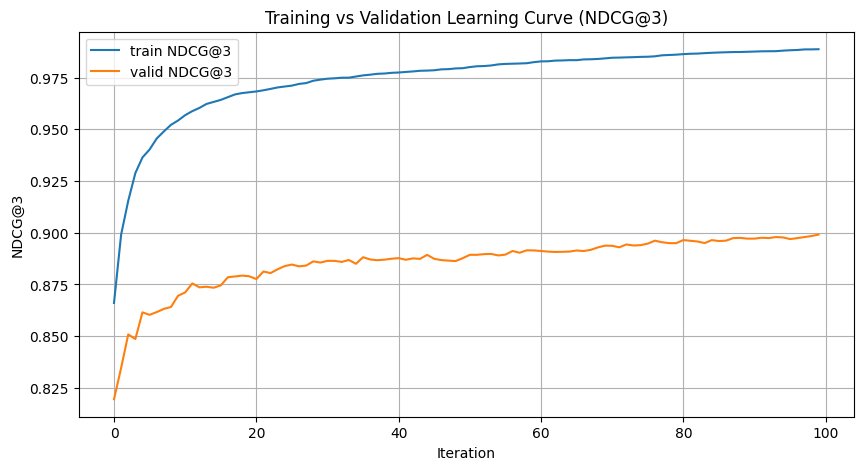

In [3]:
from pathlib import Path
import pandas as pd
import numpy as np
import lightgbm as lgb

# =========================
# 0. 설정
# =========================
SEED = 42
DATA_PATH = r"C:\Users\Admin\Desktop\hhh\Horse\data_preprocessing\merged_data_kr_Nan.csv"

TARGET = "출주두수_대비_상대순위점수"
GROUP_COL = "group_id"

# =========================
# 1. 데이터 로드
# =========================
df = pd.read_csv(DATA_PATH, encoding="utf-8-sig")

print("shape:", df.shape)

# =========================
# 2. group 생성 (경주 단위)
# =========================
df[GROUP_COL] = df["경주일자"].astype(str) + "_" + df["경주번호"].astype(str)

# =========================
# 3. ⭐ LTR 핵심: float → rank label 변환
# =========================
df["rank_label"] = df.groupby(GROUP_COL)[TARGET].rank(ascending=False).astype(int)

y = df["rank_label"]
X = df.drop(columns=[TARGET, "rank_label"])

# =========================
# 4. categorical 처리
# =========================
cat_cols = X.select_dtypes(include=["object"]).columns.tolist()

for col in cat_cols:
    X[col] = X[col].astype("category")

# =========================
# 5. group split (경주 기준)
# =========================
unique_groups = df[GROUP_COL].unique()

np.random.seed(SEED)
np.random.shuffle(unique_groups)

split = int(len(unique_groups) * 0.8)

train_groups = set(unique_groups[:split])
valid_groups = set(unique_groups[split:])

train_mask = df[GROUP_COL].isin(train_groups)
valid_mask = df[GROUP_COL].isin(valid_groups)

X_train, X_valid = X[train_mask], X[valid_mask]
y_train, y_valid = y[train_mask], y[valid_mask]

# =========================
# 6. group size 생성 (LTR 필수)
# =========================
def make_group_sizes(groups):
    return groups.value_counts().sort_index().values

group_train = make_group_sizes(df[train_mask][GROUP_COL])
group_valid = make_group_sizes(df[valid_mask][GROUP_COL])

# =========================
# 7. LightGBM Dataset
# =========================
lgb_train = lgb.Dataset(
    X_train,
    label=y_train,
    group=group_train,
    categorical_feature=cat_cols
)

lgb_valid = lgb.Dataset(
    X_valid,
    label=y_valid,
    group=group_valid,
    categorical_feature=cat_cols
)

# =========================
# 8. 모델 (LTR)
# =========================
params = {
    "objective": "lambdarank",
    "metric": "ndcg",
    "learning_rate": 0.05,
    "num_leaves": 63,
    "seed": SEED,
    "verbose": -1,
}

model = lgb.train(
    params,
    lgb_train,
    valid_sets=[lgb_valid],
    valid_names=["valid"],
    num_boost_round=50,
    callbacks=[
        lgb.early_stopping(50),
        lgb.log_evaluation(50)
    ]
)

# =========================
# 9. 예측
# =========================
pred = model.predict(X_valid)

valid_df = df[valid_mask].copy()
valid_df["pred"] = pred
valid_df["true_rank"] = y_valid.values

# =========================
# 10. 평가 (Top1 + NDCG@3)
# =========================
def dcg(scores):
    return sum(v / np.log2(i + 2) for i, v in enumerate(scores))

def evaluate(df):
    top1 = 0
    ndcgs = []

    for _, race in df.groupby(GROUP_COL):

        pred_sorted = race.sort_values("pred", ascending=False)
        true_sorted = race.sort_values("true_rank", ascending=False)

        # Top1 정확도
        if pred_sorted.iloc[0]["true_rank"] == true_sorted.iloc[0]["true_rank"]:
            top1 += 1

        # NDCG@3
        k = 3
        pred_vals = pred_sorted["true_rank"].values[:k]
        ideal_vals = true_sorted["true_rank"].values[:k]

        idcg = dcg(sorted(ideal_vals, reverse=True))
        ndcg = dcg(pred_vals) / idcg if idcg > 0 else 0

        ndcgs.append(ndcg)

    return {
        "Top1 Accuracy": top1 / df[GROUP_COL].nunique(),
        "NDCG@3": np.mean(ndcgs)
    }

metrics = evaluate(valid_df)

print("\n===== VALID METRICS =====")
print(metrics)

# =========================
# 11. Feature Importance
# =========================
fi = pd.DataFrame({
    "feature": X_train.columns,
    "importance": model.feature_importance()
}).sort_values("importance", ascending=False)

print("\n===== TOP 20 FEATURES =====")
print(fi.head(20))

train_pred = model.predict(X_train)
valid_pred = model.predict(X_valid)

train_df = df[train_mask].copy()
valid_df = df[valid_mask].copy()

train_df["pred"] = train_pred
valid_df["pred"] = valid_pred

def evaluate_simple(df):
    ndcgs = []

    for _, race in df.groupby(GROUP_COL):

        pred_sorted = race.sort_values("pred", ascending=False)

        true_vals = race[TARGET].values

        # DCG@3
        k = 3
        pred_vals = true_vals[np.argsort(-race["pred"].values)[:k]]

        def dcg(x):
            return sum(v / np.log2(i + 2) for i, v in enumerate(x))

        ideal = sorted(true_vals, reverse=True)[:k]

        idcg = dcg(ideal)
        ndcg = dcg(pred_vals) / idcg if idcg > 0 else 0

        ndcgs.append(ndcg)

    return np.mean(ndcgs)


train_ndcg = evaluate_simple(train_df)
valid_ndcg = evaluate_simple(valid_df)

print("TRAIN NDCG@3:", train_ndcg)
print("VALID NDCG@3:", valid_ndcg)

print("GAP:", train_ndcg - valid_ndcg)

evals_result = {}

model = lgb.train(
    params,
    lgb_train,
    valid_sets=[lgb_train, lgb_valid],
    valid_names=["train", "valid"],
    num_boost_round=100,   # 또는 1000
    callbacks=[
        lgb.record_evaluation(evals_result),
        lgb.log_evaluation(10)
    ]
)

import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

# NDCG@3 기준 (lightgbm 자동 metric log)
plt.plot(evals_result["train"]["ndcg@3"], label="train NDCG@3")
plt.plot(evals_result["valid"]["ndcg@3"], label="valid NDCG@3")

plt.xlabel("Iteration")
plt.ylabel("NDCG@3")
plt.title("Training vs Validation Learning Curve (NDCG@3)")
plt.legend()
plt.grid(True)
plt.show()

In [8]:
import optuna
import lightgbm as lgb
import numpy as np
import pandas as pd
from sklearn.model_selection import GroupKFold
from sklearn.metrics import ndcg_score

# =========================
# 1. 데이터 로드
# =========================
df = pd.read_csv(r"C:\Users\Admin\Desktop\hhh\Horse\data_preprocessing\merged_data_kr_Nan.csv")

TARGET = "출주두수_대비_상대순위점수"

# =========================
# 2. group_id 생성 (경마 핵심)
# =========================
df["group_id"] = (
    df["경주일자"].astype(str) + "_" +
    df["경주번호"].astype(str)
)

# =========================
# 3. 문자열 컬럼 제거 (LightGBM 필수)
# =========================
drop_cols = [
    "마명","기수번호","경주일자","경주등급",
    "출전마구분","야간경마여부","경주로상태",
    "날씨","출생일","성별","소유자명",
    "생산국","부마명","소재지"
]

X = df.drop(columns=[TARGET] + drop_cols + ["group_id"])
y = df[TARGET]
groups = df["group_id"]

# =========================
# 4. NDCG 평가 함수
# =========================
def eval_ndcg(y_true, y_pred, group):
    ndcgs = []

    for g in np.unique(group):
        idx = group == g
        yt = y_true[idx]
        yp = y_pred[idx]

        ndcgs.append(ndcg_score([yt], [yp]))

    return np.mean(ndcgs)

# =========================
# 5. Optuna objective
# =========================
def objective(trial):

    params = {
        "objective": "lambdarank",
        "metric": "ndcg",
        "boosting_type": "gbdt",
        "verbosity": -1,
        "random_state": 42,

        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.1),
        "num_leaves": trial.suggest_int("num_leaves", 16, 128),
        "max_depth": trial.suggest_int("max_depth", 3, 12),
        "min_data_in_leaf": trial.suggest_int("min_data_in_leaf", 10, 200),

        "feature_fraction": trial.suggest_float("feature_fraction", 0.6, 1.0),
        "bagging_fraction": trial.suggest_float("bagging_fraction", 0.6, 1.0),
        "bagging_freq": trial.suggest_int("bagging_freq", 1, 10),

        "lambda_l1": trial.suggest_float("lambda_l1", 0.0, 5.0),
        "lambda_l2": trial.suggest_float("lambda_l2", 0.0, 5.0),
    }

    gkf = GroupKFold(n_splits=5)
    scores = []

    for train_idx, valid_idx in gkf.split(X, y, groups):

        X_train, X_valid = X.iloc[train_idx], X.iloc[valid_idx]
        y_train, y_valid = y.iloc[train_idx], y.iloc[valid_idx]

        group_train = X_train.groupby(groups.iloc[train_idx]).size().values
        group_valid = X_valid.groupby(groups.iloc[valid_idx]).size().values

        model = lgb.LGBMRanker(**params, n_estimators=2000)

        model.fit(
            X_train,
            y_train,
            group=group_train,
            eval_set=[(X_valid, y_valid)],
            eval_group=[group_valid],
            eval_at=[1, 3, 5],
            callbacks=[
                lgb.early_stopping(100, verbose=False)
            ],
        )

        preds = model.predict(X_valid)

        score = eval_ndcg(
            y_valid.values,
            preds,
            groups.iloc[valid_idx].values
        )

        scores.append(score)

    return np.mean(scores)

# =========================
# 6. 실행
# =========================
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=50)

print("\n===== BEST RESULT =====")
print("Best NDCG:", study.best_value)
print("Best Params:", study.best_params)

[I 2026-04-28 18:39:21,593] A new study created in memory with name: no-name-0111b703-fc15-4191-ac4a-881a4bf9dfa8
[W 2026-04-28 18:39:21,634] Trial 0 failed with parameters: {'learning_rate': 0.0721785636628252, 'num_leaves': 56, 'max_depth': 6, 'min_data_in_leaf': 116, 'feature_fraction': 0.910391581664195, 'bagging_fraction': 0.9619164354487456, 'bagging_freq': 10, 'lambda_l1': 2.8104093495706266, 'lambda_l2': 2.4040792126931994} because of the following error: LightGBMError('label should be int type (met 0.636364) for ranking task,\nfor the gain of label, please set the label_gain parameter').
Traceback (most recent call last):
  File "c:\Users\Admin\Desktop\hhh\Horse\.venv\Lib\site-packages\optuna\study\_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
  File "C:\Users\Admin\AppData\Local\Temp\ipykernel_20072\686490540.py", line 90, in objective
    model.fit(
    ~~~~~~~~~^
        X_train,
        ^^^^^^^^
    ...<7 lines>...
        ],
        ^^
    )
   

LightGBMError: label should be int type (met 0.636364) for ranking task,
for the gain of label, please set the label_gain parameter

In [ ]:
# df["날씨"].unique() => 파생변수 만들기

<StringArray>
['흐림', '맑음', '비', '눈', '강풍']
Length: 5, dtype: str

In [6]:
df.columns

Index(['분할경주여부', '마명', '마번', '기수번호', '조교사번호', '부담구분', '출전번호', '경주일자', '경주등급',
       '출전마구분', '경주번호', '야간경마여부', '마필등급', '출주두수', '경주로상태', '날씨', '마체중', '출생일',
       '성별', '소유자명', '생산국', '부마명', '소재지', '출주두수_대비_상대순위점수', '평균_시속',
       'group_id', 'rank_label'],
      dtype='str')